# Global Narrative-to-Tag

#### [로컬버전 수정사항] 돌아가는 것이 최우선. 환경적으로 안되는 것은 버리자!
- 가장 안정적인 python3.12 버전으로 맞추기 (3.12에 맞지 않으면 다 버림)
- 양자화 포기.... (GPU 요구사항이 안맞음)
- 아주 허무하게... 포기할꺼 포기하니 한번에 된다...

### [프로젝트 요구사항]

#### 1.1 필수 구현 항목:

**FastAPI 백엔드**
   - 추론 엔드포인트 (POST /predict)
   - Pydantic으로 입력 검증
   - 비동기 추론 (run_in_executor)   

**API Key 인증**
   - Day 6의 auth.py 재사용  

**Streamlit 프론트엔드**
   - 사용자 입력 → API 호출 → 결과 표시  
   
**에러 처리**
   - 잘못된 입력, 모델 에러 시 적절한 HTTP 상태 코드 반환

#### 1.2 제한 사항

- 모델 학습 (사전학습 모델을 가져다 씁니다)
- Docker 패키징 (MLOps 과정에서 다룹니다)
- 데이터베이스 연동

#### 1.3 평가 기준

✅ 서버가 정상적으로 실행되는가?  
✅ Swagger UI에서 추론이 동작하는가?  
✅ API Key 없이 요청하면 401이 반환되는가?  
✅ 잘못된 입력에 대해 적절한 에러 메시지가 나오는가?  
✅ Streamlit UI에서 입력 → 결과 확인이 가능한가?  

## 0.🚀 프로젝트 설계

### 0-0. 프로젝트 정의서: Global Narrative-to-Tag (PoC)

#### **1) 프로젝트 목표**
최대 5000자의 웹소설/웹툰 대본(서사 텍스트)을 입력받아, 단락별로 다국어 번역과 핵심 키워드(태그) 추출을 동시에 수행하는 지능형 현지화 파이프라인의 프로토타입 구축

#### **2) 핵심 구현 기능 (기능 명세)**
*   **프론트엔드 (Streamlit):**
    *   최대 5000자를 입력받을 수 있는 넓은 텍스트 박스(`st.text_area`) 제공.
    *   원문 작품을 [ [단락코드,[문장1,문장2, ... , 문장N]], [단락코드',[문장1',문장2',..., 문장N'], ...] 형태의 리스트로 변환 (시간 절약을 위해 복잡한 NLP 문장 분리기 대신, 파이썬 기본 줄바꿈(\n}이나 마치미표(.)을 기준으로 단란을 쪼개기)
    *  사전 학습 모델을 사용 문장 분석 하여 [[단락코드,[원본 문장, 번역된 문장,[추출된 태그]]] 형태의 리스트로 결과 출력.
*   **백엔드 (FastAPI + run_in_executor):**
    *   `POST /analyze` 엔드포인트 구현.
    *   5000자의 긴 텍스트를 처리하는 동안 서버가 멈추지 않도록(Blocking 방지) 추론 작업을 `ThreadPoolExecutor`와 `run_in_executor`를 활용해 별도 스레드에서 처리.
*   **AI 파이프라인 (Hugging Face):**
    *   **Translation:** 한국어 단락을 영어 등 타겟 언어로 번역.
    *   **Zero-Shot Tagging:** 각 단락을 미리 정의해 둔 후보 키워드(예: `["액션", "로맨스", "심리", "반전", "배경묘사"]`) 중 확률이 가장 높은 것으로 매핑.

### 0-1. 백엔드 설계

#### 1) 텍스트 입력 및 전처리
- 사용자가 텍스트를 입력하거나 txt 파일을 불러오면 \n과 .을 기준으로 문단별 문장으로 분리.
- [[[문장타입, 문장1], [문장타입, 문장2], ...], ...] 형태의 리스트로 변경.
- 문장 타입 분류: 일반(0), 대사(" 쌍따옴표로 감싸진 문장, 1), 생각(' 작은따옴표로 감싸진 문장, 2).
- 불필요한 특수 문자 모두 제거.
- 파일 저장: data 폴더 안에 VALID_API_KEYS의 사용자명으로 새로운 폴더를 생성하여 파일 저장.
- 파일명 규칙: YYYYMMDDHHMMSS + 랜덤 3자리 숫자.txt 형식으로 지정하여 같은 폴더에 저장.
#### 2) 문장 추출
- 1단계에서 만들어진 문단별 문장 리스트에서 문장만 별도의 리스트([])로 추출.
#### 3) 번역 변환 (translator_model)
- 번역된 결과를 translator_result = [[문장타입, [원문문장, 번역문장]], ...] 형태로 변환.
#### 4) 키워드 추출 (quantized_model)
- 원문 문장과 번역 문장의 키워드를 추출. (문장별로 추출 시 개수가 너무 많아지므로 문단별 추출 진행)
- quantized_result = [[[[문장타입, 원문문장, 번역문장], [문장타입, 원문문장, 번역문장]], [원문키워드, 번역문장키워드]], ...] 형태로 저장.
#### 5) 결과 딕셔너리 생성
- 전체 문단 및 문장에 대한 키워드 중 빈도수가 가장 높은 원문 키워드와 번역 문장 키워드를 상위 5개씩 추출.
- 결과 포맷: {'title': "작품제목", 'origin_txt': "data의 user 폴더 안에 생성된 txt 파일 path", 'keyword': [[원문키워드], [영문키워드]], 'data': quantized_result}
#### 6) JSON 파일 저장
- 5단계에서 생성한 딕셔너리를 JSON 형태로 변환.
- data 폴더 내 해당 사용자(user)의 폴더에 저장하되, 파일명은 오리지널 txt 파일 이름과 동일하게 설정.


### 0-2. 프론트엔드 설계

#### 1) 우측 사이드바
- API 키 입력창
- 내가 그동안 작성한 작품 리스트 선택 메뉴
#### 2) 메인 화면 (입력부)
- 서비스 타이틀 및 서비스 소개
- 작품 제목 입력창
- 기능 탭 구성:
  - [파일로 불러오기] 탭: 파일 선택창, 확인 버튼
  - [작품 입력하기] 탭: 텍스트 입력창 (크기 조절 가능 + 글자 수 세기 지원), 임시저장 버튼 (임시저장 시 status에 저장), 임시저장된 파일 불러오기 버튼, 확인 버튼
#### 3) 작품 출력 화면 (결과부)
- 작품 제목
- 출력 내용 선택 버튼: 원문 보기, 번역본 보기, 원문+번역 대조 보기
- 출력 형태 선택 버튼: <p> 태그를 원래 display 형태인 block으로 보여줄지, inline으로 보여줄지 선택
- 작품 키워드: 출력 형태 선택에 따라 원문 키워드, 번역본 키워드, 혹은 둘 다(원문+번역) 출력
#### 4) 작품 렌더링 규칙
- 모든 문단은 `<section>` 태그로 감싸기.
- 각 문장은 `<p>` 태그로 감싸기.
- 대사나 생각 문장에는 class 속성을 추가하고, 해당 속성에 따라 ::before와 ::after 가상 요소를 활용해 작은따옴표(')와 쌍따옴표(")를 화면에 출력.
- 대사나 생각 문장은 무조건 display: block으로 설정.




## 01. 사전 준비

- 가상환경 세팅: `py -3.12 -m venv .venv`  
    -  만약 py 명령어가 안 먹힌다면, `python3.12 -m venv .venv`로 시도
    - 버전확인: `.venv\Scripts\python --version`
- 커널등록  
`.venv\Scripts\python -m pip install ipykernel`  
`.venv\Scripts\python -m ipykernel install --user --name .venv --display-name="Python(Global_NtoT)"`
- 가상환경 활성화: `.venv\Scripts\Activate.ps1`
- `Windows 보안` - `앱 및 브라우저 컨트롤` - `스마트 앱 컨트롤` 끄기
- `설정` - `시스템` - `고급` - `개발자용` - `개발자 모드` 켬

### 📃requirements.txt 파일 만들기

In [ ]:
%%writefile requirements.txt
# ===== Core =====
# 1. PyTorch 보안 이슈(CVE-2025-32434) 해결을 위해 2.6.0 이상 강제
torch>=2.6.0
torchvision>=0.16.0

# ===== LLM & Quantization =====
# 2. bitsandbytes 0.44.1과 완벽히 호환되며 번역 파이프라인이 안정적인 버전으로 고정
transformers==4.44.2
accelerate
# 3. Colab CUDA 12.x 환경과의 충돌(libnvJitLink.so.13 에러) 방지
bitsandbytes==0.44.1

# ===== Translation & Tokenization =====
sentencepiece
protobuf
sacremoses         # 4. Helsinki-NLP 번역 파이프라인(MarianMT) 필수 의존성 추가

# ===== API =====
fastapi==0.115.0
uvicorn[standard]==0.30.0
pydantic>=2.0.0,<3.0.0

# ===== Frontend =====
streamlit==1.38.0

# ===== Utilities =====
nest-asyncio
requests>=2.31.0,<3.0.0
pillow>=10.0.0
python-multipart>=0.0.6

In [ ]:
! pip install -r requirements.txt

## 02. 모델 선택

### 다국어 기계 번역 (한국어 → 영어)

- 모델명: Helsinki-NLP/opus-mt-ko-en
- Model page: https://huggingface.co/Helsinki-NLP/opus-mt-ko-en
- opus_readme_url: https://github.com/Helsinki-NLP/Tatoeba-Challenge/tree/master/models/kor-eng/README.md
- repo_id: Helsinki-NLP/opus-mt-ko-en

In [2]:
from transformers import pipeline
# 본인이 선택한 모델로 교체하세요
translator = pipeline("translation", model="Helsinki-NLP/opus-mt-ko-en")
# 2. 번역 테스트
sample_text = ["주인공은 어두운 숲 속에서 전설의 검을 발견했다.", "그리고 마왕을 향해 걸어갔다."]
translated_result =translator(sample_text)
print(translated_result)
# [{'label': 'positive', 'score': 0.95}]

[{'translation_text': 'The hero found the sword of legend in the dark forest.'}, {'translation_text': 'And I walked toward the Dark One.'}]


### 제로샷 카테고리 분류 (다국어 지원)

- 모델명: MoritzLaurer/mDeBERTa-v3-base-mnli-xnli
- Model page: https://huggingface.co/MoritzLaurer/mDeBERTa-v3-base-mnli-xnli

##### 📟 기본 코드

In [3]:
import torch
from transformers import pipeline


model_id = "MoritzLaurer/mDeBERTa-v3-base-mnli-xnli"


# DeBERTa 모델은 device_map="auto"를 지원하지 않으므로 GPU 사용을 위해 명시적으로 device 인자를 지정합니다.
device_id = 0 if torch.cuda.is_available() else -1


# 2. 파이프라인에 직접 모델 로드
classifier = pipeline(
    "zero-shot-classification",
    model=model_id,
    device=device_id
)


# 3. 오프라인 LLM으로 미리 뽑아둔 '후보 키워드' (예시)
candidate_labels = ["액션", "마법", "성장", "반전", "배경묘사"]


# 4. 분류 테스트
# (sample_text는 이전 셀에서 정의된 변수를 사용합니다)
if 'sample_text' not in locals():
    sample_text = "주인공은 어두운 숲 속에서 전설의 검을 발견했다."


results = classifier(sample_text, candidate_labels)


print("\n=== 제로샷 분류(태깅) 결과 ===")
# 결과가 단일 딕셔너리인지 리스트인지 확인 후 반복문 처리
if isinstance(results, dict):
    results = [results]


for result in results:
    print(f"원문: {result['sequence']}")
    print(f"가장 높은 확률의 태그: {result['labels'][0]} (점수: {result['scores'][0]:.4f})")
    print(f"두 번째 높은 확률의 태그: {result['labels'][1]} (점수: {result['scores'][1]:.4f})\n")

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`



=== 제로샷 분류(태깅) 결과 ===
원문: 주인공은 어두운 숲 속에서 전설의 검을 발견했다.
가장 높은 확률의 태그: 마법 (점수: 0.7684)
두 번째 높은 확률의 태그: 배경묘사 (점수: 0.0910)

원문: 그리고 마왕을 향해 걸어갔다.
가장 높은 확률의 태그: 반전 (점수: 0.4913)
두 번째 높은 확률의 태그: 액션 (점수: 0.4211)



## 3. 프로젝트 뼈대

### 3-1.📁프로젝트 폴더 구성 세팅

In [ ]:
import os

folders = [
    "app",             # FastAPI 애플리케이션 코드
    "frontend",        # Streamlit 프론트엔드 코드
    "models",
    "data",            # 샘플 데이터
    "tests",           # 테스트 코드
]
for folder in folders:
    os.makedirs(folder, exist_ok=True)
    print(f"✅ {folder}/ 생성 완료")

### 3-2.📜auth.py — 재사용

In [ ]:
%%writefile app/auth.py
"""
Day 6에서 만든 인증 모듈을 그대로 재사용합니다.
"""
from fastapi import HTTPException, Header

VALID_API_KEYS = {
    "test-key-001": "user01",
    "test-key-002": "user02",
}


async def verify_api_key(x_api_key: str = Header(None)) -> str:
    if x_api_key is None:
        raise HTTPException(
            status_code=401,
            detail="API Key가 필요합니다. X-API-Key 헤더를 포함해 주세요.",
        )
    if x_api_key not in VALID_API_KEYS:
        raise HTTPException(
            status_code=401,
            detail="유효하지 않은 API Key입니다.",
        )
    return VALID_API_KEYS[x_api_key]

### 3-3.📝schemas.py — 구조 변경

In [ ]:
"""
입력/출력 스키마.

"""
from pydantic import BaseModel, Field
from typing import List, Optional, Literal
from pydantic import BaseModel, field_validator

class NarrativeRequest(BaseModel):
    title: str
    text: str

# ---------------------------------------------------------
# [요청 스키마]
# ---------------------------------------------------------
class NarrativeRequest(BaseModel):
    """
    사용자로부터 텍스트를 입력받는 요청 모델 (단계 1의 입력)
    """
    title: str = Field(..., description="작품 제목 (필수)")
    # min_length, max_length로 길이를 엄격히 검증
    text: str = Field(..., min_length=1, max_length=5000, description="분석할 서사 텍스트 (최대 5000자) (필수)")

    @field_validator('title', 'text', mode='before')
    @classmethod
    def normalize_quotes(cls, value: str) -> str:
        if not isinstance(value, str):
            return value
            
        # 1. 스마트 따옴표 맵핑 규칙 생성
        # 왼쪽 문자열의 각 문자를 오른쪽 문자열의 같은 위치 문자로 1:1 변환
        quote_map = str.maketrans("‘’`“”", "'''\"\"")
        
        # 2. 변환 적용
        normalized_text = value.translate(quote_map)
        
        return normalized_text


# ---------------------------------------------------------
# [응답 데이터 세부 구조]
# ---------------------------------------------------------
class SentenceDetail(BaseModel):
    """
    개별 문장 분석 결과 구조
    """
    original_text: str = Field(..., description="원문 문장 (필수)")
    translated_text: Optional[str] = Field(default=None, description="번역된 문장 (선택)")


class ParagraphDetail(BaseModel):
    """
    문단별 분석 결과 구조 (단계 4의 quantized_result 단위)
    """
    paragraph_type: int = Field(..., ge=0, le=2, description="0: 일반, 1: 대사, 2: 생각 (필수)")
    sentences: List[SentenceDetail] = Field(..., description="문단 내 문장들 (필수)")
    # 모델 추론 결과에 따라 키워드가 없을 수도 있으므로 선택 필드 처리
    keywords: Optional[List[List[str]]] = Field(default=None, description="[원문키워드 리스트, 영문키워드 리스트] (선택)")


# ---------------------------------------------------------
# [최종 응답 스키마]
# ---------------------------------------------------------
class NarrativeResponse(BaseModel):
    """
    API의 최종 응답 모델 (단계 5, 6의 딕셔너리 구조)
    """
    title: str = Field(..., description="작품 제목 (필수)")
    # 파일 저장을 선택적 기능으로 처리할 경우를 가정한 선택 필드 처리
    origin_txt: Optional[str] = Field(default=None, description="data 폴더 안에 생성된 txt 파일 path (선택)")
    keyword: Optional[List[List[str]]] = Field(default=None, description="전체 상위 5개 추출 키워드 [[원문키워드], [영문키워드]] (선택)")
    data: List[ParagraphDetail] = Field(..., description="문단별 상세 분석 데이터 (quantized_result) (필수)")


### 3-4.📝model_service.py — 구조 변경에 따른 코드 수정

In [ ]:
# keyword.txt 파일을 읽어 리스트에 담는 코드
with open('data/keyword.txt', 'r', encoding='utf-8') as file:
    content = file.read()
    # 쉼표(,)로 구분하고 각 키워드의 양쪽 공백을 제거하여 리스트로 생성
    keyword_list = [keyword.strip() for keyword in content.split(',')]

print(keyword_list)

In [ ]:
%%writefile app/model_service.py
"""
모델 직접 로드 및 추론 함수 (TensorFlow 폴백 원천 차단 버전)
"""
import os
import re
import json
import random
import torch
import traceback
from datetime import datetime
from collections import Counter
from transformers import pipeline, AutoTokenizer, AutoModelForSeq2SeqLM, AutoModelForSequenceClassification
from fastapi import FastAPI, Depends, HTTPException

try:
    with open('data/keyword.txt', 'r', encoding='utf-8') as file:
        content = file.read()
        KOREAN_KEYWORDS = [keyword.strip() for keyword in content.split(',')]
except FileNotFoundError:
    KOREAN_KEYWORDS = ["로맨스", "판타지", "액션", "무협", "스릴러"]

ENGLISH_KEYWORDS = ["Romance Fantasy", "Modern Romance", "Traditional Fantasy", "Modern Fantasy", "Martial Arts", "Mystery", "Thriller", "Apocalypse", "Slice of Life", "RomCom", "Revenge", "Coming-of-age", "Healing", "Angst", "Comedy", "Calm", "Contract Dating", "Arranged Marriage", "First Love", "Mutual Salvation", "Misunderstanding", "Reverse Harem", "Harem", "Status Difference", "Capable FL", "Girl Crush FL", "Regression FL", "Reincarnation FL", "Possession FL", "Sweet ML", "Tsundere ML", "Cold Handsome ML", "Obsessive ML", "Crazy Obsessive ML", "Regretful ML", "Pure Love ML", "Straightforward ML", "Sly ML", "Scarred FL", "Mastermind ML", "Genius ML", "Satisfying Plot", "Brain Battle", "Psychological", "Plot Twist", "Solid World-building", "Foreshadowing Retrieval", "Solid Emotional Line", "Dark Fantasy", "Noir"]

def load_model():
    """
    AutoModel로 직접 PyTorch 모델을 로드하여 파이프라인에 주입합니다.
    """
    # 0번 GPU 사용, 없으면 CPU(-1)
    device = 0 if torch.cuda.is_available() else -1

    # ==========================================
    # 1. 번역 모델 (강제 PyTorch 로드)
    # ==========================================
    trans_model_id = "Helsinki-NLP/opus-mt-ko-en"
    trans_tokenizer = AutoTokenizer.from_pretrained(trans_model_id)
    trans_model = AutoModelForSeq2SeqLM.from_pretrained(trans_model_id)

    translator = pipeline(
        "translation",
        model=trans_model,
        tokenizer=trans_tokenizer,
        device=device
    )

    # ==========================================
    # 2. 제로샷 태깅 모델 (강제 PyTorch 로드)
    # ==========================================
    tagger_model_id = "MoritzLaurer/mDeBERTa-v3-base-mnli-xnli"
    tagger_tokenizer = AutoTokenizer.from_pretrained(tagger_model_id)
    tagger_model = AutoModelForSequenceClassification.from_pretrained(tagger_model_id)

    tagger = pipeline(
        "zero-shot-classification",
        model=tagger_model,
        tokenizer=tagger_tokenizer,
        device=device
    )

    return {"translator": translator, "tagger": tagger}

    
def predict(model: dict, input_data: dict) -> dict:
    """
    입력을 받아 로직을 수행하고 추론 결과를 반환합니다.
    """
    translator = model["translator"]
    tagger = model["tagger"]

    text = input_data["text"]
    title = input_data["title"]
    username = input_data["username"]

    os.makedirs(f"data/{username}", exist_ok=True)
    base_filename = datetime.now().strftime("%Y%m%d%H%M%S") + str(random.randint(100, 999))
    txt_path = f"data/{username}/{base_filename}.txt"

    with open(txt_path, "w", encoding="utf-8") as f:
        f.write(text)
    print(f"\n=== [STEP 2-1] 텍스트 파일 {base_filename}.txt 저장완료===")
    paragraphs = text.split('\n')
    print(f"\n=== [STEP 2-2] 문단 분할 완료.( 총 문단개수 : {len(paragraphs)}개 )===")

    parsed_paragraphs = []
    len_p = 0
    try:
        for p in paragraphs:
            clean_p = p.strip()
            if not clean_p: 
                continue

            # 1. 문단 타입 판별 (문장으로 쪼개기 전, 원본 문단 기준)
            p_type = 0
            if clean_p.startswith('"') and clean_p.endswith('"'):
                p_type = 1
            elif clean_p.startswith("'") and clean_p.endswith("'"):
                p_type = 2

            # 2. 문단 내 문장 분리
            sentences = [s.strip() + '.' for s in clean_p.split('.') if s.strip()]
            
            para_sents = []
            for s in sentences:
                # 특수문자 정제
                clean_s = re.sub(r'[^a-zA-Z0-9가-힣\s\'".,!?]', '', s).strip()
                if clean_s: 
                    para_sents.append(clean_s)

            # 문단 타입(p_type)과 문장 리스트를 함께 저장
            if para_sents:
                parsed_paragraphs.append([p_type, para_sents])
            len_p = len_p + len(para_sents)
            print(f"\n 문단타임: {p_type}, 문단내 문장 갯수: {len(para_sents)} (누적 문장 갯수:{len_p})")
        len_s = len(parsed_paragraphs)
        
        print(f"\n=== [STEP 2-3] 모든 문단 타입 판별이 완료되었습니다.( 총 문단개수 : {len(parsed_paragraphs)}개 )===")
    except Exception as e:
        # [핵심 디버깅 구간] 에러 발생 시 터미널에 상세 내역을 붉은 글씨로 쫙 뿌려줍니다.
        print("\n" + "="*50)
        print("🚨 [CRITICAL ERROR] 문단별 문장 분할 중 에러 발생! 🚨")
        traceback.print_exc()  # 에러가 발생한 파일과 줄 번호를 출력합니다.
        print("="*50 + "\n")

        raise HTTPException(status_code=500, detail=f"문단별 문장 분할 중 에러가 발생했습니다: {str(e)}")

    quantized_result = []
    all_orig_keywords = []
    all_trans_keywords = []
    len_t = 0

    try:
        for p_type, sentences in parsed_paragraphs:
            para_translated = []
            trans_sentences = []
            para_orig_text = ""
            para_trans_text = ""

            # 1. [핵심 최적화] 문장 리스트를 통째로 번역 모델에 전달 (Batch Processing)
            # GPU 환경이라면 batch_size를 추가하여 연산 속도를 극대화할 수 있습니다.
            translation_results = translator(sentences, batch_size=8)

            # (방어 코드) 문장이 1개라서 리스트가 아닌 단일 딕셔너리로 반환될 경우 대비
            if not isinstance(translation_results, list):
                translation_results = [translation_results]

            # 2. 원문 문장과 번역 결과를 1:1로 매핑
            for orig_sent, result in zip(sentences, translation_results):
                if isinstance(result, list) and len(result) > 0:
                    trans_sent = result[0].get('translation_text', '')
                elif isinstance(result, dict): # 단일 딕셔너리 구조일 때
                    trans_sent = result.get('translation_text', '')
                else:
                    trans_sent = ""
                len_t = len_t + 1
                if ( len_t % 10 == 0 ):
                    print(f"문장번역 {len_p}개 중 {len_t}개 완료")
                para_translated.append([orig_sent, trans_sent])
                trans_sentences.append(trans_sent)
            
            # 3. [문자열 최적화] += 대신 파이썬 내장 join() 메서드 사용
            para_orig_text = " ".join(sentences)
            para_trans_text = " ".join(trans_sentences)
            print("문단별 태그 추출")
            # 4. 태그 추출 로직 (기존과 동일)
            orig_tags = tagger(para_orig_text, KOREAN_KEYWORDS, multi_label=True)
            trans_tags = tagger(para_trans_text, ENGLISH_KEYWORDS, multi_label=True)

            para_orig_keys = orig_tags['labels'][:3]
            para_trans_keys = trans_tags['labels'][:3]

            all_orig_keywords.extend(para_orig_keys)
            all_trans_keywords.extend(para_trans_keys)

            # 앞서 논의된 [문단타입, 문장리스트, 키워드리스트] 구조로 저장
            quantized_result.append([p_type, para_translated, [para_orig_keys, para_trans_keys]])
    except Exception as e:
        # [핵심 디버깅 구간] 에러 발생 시 터미널에 상세 내역을 붉은 글씨로 쫙 뿌려줍니다.
        print("\n" + "="*50)
        print("🚨 [CRITICAL ERROR] 번역 중 에러 발생! 🚨")
        traceback.print_exc()  # 에러가 발생한 파일과 줄 번호를 출력합니다.
        print("="*50 + "\n")

        raise HTTPException(status_code=500, detail=f"번역작업 중 에러가 발생했습니다: {str(e)}")

    top_orig = [k for k, v in Counter(all_orig_keywords).most_common(5)]
    top_trans = [k for k, v in Counter(all_trans_keywords).most_common(5)]

    final_dict = {
        "title": title,
        "origin_txt": txt_path,
        "keyword": [top_orig, top_trans],
        "data": quantized_result
    }

    json_path = f"data/{username}/{base_filename}.json"
    with open(json_path, "w", encoding="utf-8") as f:
        json.dump(final_dict, f, ensure_ascii=False, indent=2)

    return final_dict


### 3-5.📝main.py — 구조 변경에 따른 코드 수정

In [ ]:
%%writefile app/main.py
"""
FastAPI 서버 정의
"""
import re
import asyncio
import traceback
from concurrent.futures import ThreadPoolExecutor
from fastapi import FastAPI, Depends, HTTPException
from typing import List, Optional
from pydantic import BaseModel, Field

# 이전에 작성해둔 인증 모듈과 스키마 파일 로드
from app.auth import verify_api_key
from app.schemas import NarrativeRequest, NarrativeResponse
from app.model_service import load_model, predict

# 1. FastAPI 앱 생성
app = FastAPI(
    title="Localization Pipeline API",
    description="다국어 번역과 핵심 키워드(태그) 추출을 동시에 수행하는 지능형 파이프라인 API",
    version="1.0.0"
)

# 블로킹 방지를 위한 추론 전용 스레드풀 (Colab L4 환경 고려)
inference_executor = ThreadPoolExecutor(max_workers=2, thread_name_prefix="inference")

# 전역 모델 변수
pipeline_models = None


 # 1. root 추가
@app.get("/")
def read_root():
    return {"message": "Welcome to Global Narrative to Tag API!"}

# 2. startup 이벤트에서 모델 로드
@app.on_event("startup")
async def startup_event():
    global pipeline_models
    try:
        print("모델 다운로드 중...")
        pipeline_models = load_model()
        print("✅ 모델 로드 완료")
    except Exception as e:
        print(f"❌ 모델 로드 실패: {e}")
        print("--- 상세 에러 트레이스 ---")
        traceback.print_exc() # 상세 에러 스택 로깅
        print("----------------------")
        pipeline_models = None

# 3. GET /health 엔드포인트
@app.get("/health", tags=["System"])
async def health_check():
    """서버 상태와 모델 로드 여부를 확인합니다."""
    return {
        "status": "healthy" if pipeline_models is not None else "loading",
        "model_loaded": pipeline_models is not None
    }

# 4. POST /predict 엔드포인트
@app.post("/predict", response_model=NarrativeResponse, tags=["Inference"])
async def predict_endpoint(
    request: NarrativeRequest,            # Pydantic 스키마로 5000자 길이 등 입력 검증
    user: str = Depends(verify_api_key)   # X-API-Key 헤더 인증 적용 및 username 획득
):
    """최대 5000자의 서사 텍스트를 분석하여 번역 및 키워드를 추출합니다."""

    if pipeline_models is None:
        raise HTTPException(
            status_code=503,
            detail="모델이 아직 로드되지 않았습니다. 서버 상태를 확인해주세요."
        )

    # 1) 추론 서비스로 넘길 입력 데이터 구성 (청킹 적용)
    input_data = {
        "title": request.title,
        "text": request.text, # 문자열을 쪼갠 리스트(List)로 변환하여 삽입,
        "username": user
    }

    try:
        print("\n=== [STEP 1] 데이터 준비 완료 ===")
        print(f"- 제목: {input_data['title']}")
        print(f"- 텍스트 길이: {len(input_data['text'])}")

        # 2) run_in_executor로 비동기 추론 (get_running_loop 권장 반영)
        loop = asyncio.get_event_loop()

        print("\n=== [STEP 2] 추론 시작 ===")
        inference_result = await loop.run_in_executor(
            inference_executor,
            predict,
            pipeline_models,
            input_data
        )
        print("=== [STEP 3] 모델 추론 완료 ===")
        print(f"- 반환된 데이터 타입: {type(inference_result)}")
        
        # 3) 결과값이 리스트로 반환될 경우 딕셔너리를 추출 (500 에러 해결책)
        if isinstance(inference_result, list):
            if not inference_result:
                raise ValueError("추론 결과가 비어있습니다.")
            result_dict = inference_result[0]
        else:
            result_dict = inference_result

        print("=== [STEP 4] 딕셔너리 추출 완료 ===")
        # 딕셔너리가 맞는지, 어떤 키(key)들을 가지고 있는지 출력
        if isinstance(result_dict, dict):
            print(f"- 딕셔너리 키 목록: {list(result_dict.keys())}")
            print(f"- data 항목 존재 여부: {'data' in result_dict}")
        else:
            print(f"- ⚠️ 경고: result_dict가 딕셔너리가 아닙니다! 타입: {type(result_dict)}")

        # 4) 반환 딕셔너리를 Pydantic 스키마 구조에 맞게 안전하게 매핑
        formatted_data = []

        # 여기서 에러가 날 확률이 높으므로 직전에 로그 출력
        print("=== [STEP 5] Pydantic 스키마 매핑 시작 ===")
        for para_info in result_dict.get("data", []):
            # 💡 1. para_info 구조 변경 반영: [문단타입, 문장리스트, 키워드리스트]
            p_type = para_info[0] if len(para_info) > 0 else 0
            sentences_list = para_info[1] if len(para_info) > 1 else [] 
            keywords_list = para_info[2] if len(para_info) > 2 else None 

            formatted_sentences = []
            for sent_info in sentences_list:
                # 💡 2. sent_info 구조 변경 반영: [원문문장, 번역문장] (문장 타입 제거됨)
                orig = sent_info[0] if len(sent_info) > 0 else ""
                trans = sent_info[1] if len(sent_info) > 1 else None

                # SentenceDetail 스키마 규격에 맞춤
                formatted_sentences.append({
                    "original_text": orig,
                    "translated_text": trans
                })

            # 💡 3. ParagraphDetail 스키마 규격에 맞춤 (sentence_type -> paragraph_type 필드명 변경)
            formatted_data.append({
                "paragraph_type": p_type,
                "sentences": formatted_sentences,
                "keywords": keywords_list
            })
        print("=== [STEP 6] 매핑 완료, 최종 응답 반환 ===")
        # 5) 최종 응답 객체 반환 (NarrativeResponse 스키마 규격에 맞춤)
        return NarrativeResponse(
            title=result_dict.get("title", request.title), # 모델 결과에 없으면 요청 title 사용
            origin_txt=result_dict.get("origin_txt"),      # Optional (없으면 None)
            keyword=result_dict.get("keyword"),            # Optional (없으면 None)
            data=formatted_data
        )

    except Exception as e:
        # [핵심 디버깅 구간] 에러 발생 시 터미널에 상세 내역을 붉은 글씨로 쫙 뿌려줍니다.
        print("\n" + "="*50)
        print("🚨 [CRITICAL ERROR] 파이프라인 처리 중 예외 발생! 🚨")
        traceback.print_exc()  # 에러가 발생한 파일과 줄 번호를 출력합니다.
        print("="*50 + "\n")

        raise HTTPException(status_code=500, detail=f"파이프라인 처리 중 에러가 발생했습니다: {str(e)}")



### 3-6.📝frontend/app.py — 직접 작성

In [ ]:
%%writefile frontend/app.py
"""
Streamlit 프론트엔드
"""
import streamlit as st
import requests

# [API 엔드포인트 설정]
API_URL = "http://localhost:8000/predict"

# [세션 상태(Session State) 초기화]
if "temp_text" not in st.session_state:
    st.session_state["temp_text"] = ""
if "current_input" not in st.session_state:
    st.session_state["current_input"] = ""
if "api_result" not in st.session_state:
    st.session_state["api_result"] = None
if "history_works" not in st.session_state:
    st.session_state["history_works"] = []

# ---------------------------------------------------------
# 1. 페이지 및 사이드바 설정 [1, 3]
# ---------------------------------------------------------
st.set_page_config(page_title="지능형 현지화 파이프라인", layout="wide")

with st.sidebar:
    st.header("⚙️ 설정")
    # 사이드바에 API Key 입력 [3]
    api_key = st.text_input("API Key 입력", type="password", help="발급받은 API 키를 입력하세요.")
    st.divider()
    # 그동안 작성한 작품 리스트 선택
    st.selectbox("내가 작성한 작품 리스트", ["선택하세요..."] + st.session_state["history_works"])

# ---------------------------------------------------------
# 2. 메인 화면 - 서비스 소개 및 입력부 [1, 4]
# ---------------------------------------------------------
# st.title()로 제목
st.title("지능형 현지화 파이프라인")
st.markdown("최대 5000자의 서사 텍스트를 입력받아 **다국어 번역**과 **핵심 키워드 추출**을 수행하는 프로토타입입니다.")

# 작품 제목 입력창
work_title = st.text_input("작품 제목", placeholder="작품의 제목을 입력해주세요.")

# 분석 실행을 위한 공통 함수 (버튼 클릭 시 requests.post()로 API 호출) [1, 2]
def analyze_text(title, text):
    if not title or not text:
        st.warning("작품 제목과 텍스트를 모두 입력해주세요.")
        return
    if not api_key:
        st.warning("우측 사이드바에 API Key를 입력해주세요.")
        return

    with st.spinner("번역 및 키워드 추출을 진행 중입니다..."):
        headers = {"X-API-Key": api_key}
        payload = {"title": title, "text": text}
        try:
            response = requests.post(API_URL, json=payload, headers=headers)
            response.raise_for_status()

            # 결과 저장 및 히스토리 업데이트
            st.session_state["api_result"] = response.json()
            if title not in st.session_state["history_works"]:
                st.session_state["history_works"].append(title)

            st.success("분석이 완료되었습니다!")
        except requests.exceptions.HTTPError as e:
            st.error(f"API 호출 실패 (HTTP {e.response.status_code}): {e.response.text}")
        except Exception as e:
            st.error(f"서버에 연결할 수 없습니다: {e}")

# 탭 구성: 파일로 불러오기 / 작품 입력하기
tab1, tab2 = st.tabs(["📁 파일로 불러오기", "✍️ 작품 입력하기"])

with tab1:
    # 본인의 모델에 맞는 입력 위젯 (file_uploader)
    uploaded_file = st.file_uploader("분석할 텍스트 파일(.txt)을 업로드하세요", type=["txt"])
    file_text = ""
    if uploaded_file:
        file_text = uploaded_file.read().decode("utf-8")
        st.text_area("파일 내용 미리보기", file_text, height=150, disabled=True)

    if st.button("확인 (파일 분석)"):
        analyze_text(work_title, file_text)

with tab2:
    # 본인의 모델에 맞는 입력 위젯 (text_input/text_area)
    current_input = st.text_area(
        "서사 텍스트 입력 (최대 5000자)",
        value=st.session_state["current_input"],
        height=300,
        max_chars=5000
    )
    # 글자수 세기
    st.caption(f"현재 글자수: {len(current_input)} / 5000자")

    col1, col2, col3 = st.columns(3)
    with col1:
        if st.button("💾 임시저장"):
            st.session_state["temp_text"] = current_input
            st.success("상태(Status)에 임시저장되었습니다.")
    with col2:
        if st.button("📂 임시저장 파일 불러오기"):
            st.session_state["current_input"] = st.session_state["temp_text"]
            st.rerun()  # 화면을 새로고침하여 불러온 텍스트 반영 [5]
    with col3:
        if st.button("확인 (텍스트 분석)"):
            st.session_state["current_input"] = current_input
            analyze_text(work_title, current_input)

# ---------------------------------------------------------
# 3. 작품 출력 화면 (결과 표시) [4, 6]
# ---------------------------------------------------------
if st.session_state["api_result"]:
    st.divider()
    result = st.session_state["api_result"]

    # 작품 제목
    st.header(f"📖 {result['title']}")

    # 제어 옵션 레이아웃
    ctrl_col1, ctrl_col2 = st.columns(2)
    with ctrl_col1:
        # 출력 내용 선택
        view_option = st.radio(
            "출력 내용 선택",
            ["원문보기", "번역본보기", "원문+번역 대조보기"],
            horizontal=True
        )
    with ctrl_col2:
        # 출력 형태 선택 (p태그 display 제어)
        format_option = st.radio(
            "출력 형태 선택",
            ["Block (단락별 줄바꿈)", "Inline (자연스럽게 이어쓰기)"],
            horizontal=True
        )

    # 작품 키워드 출력 (출력 형태에 따라 분기)
    st.subheader("🔑 작품 핵심 키워드")
    top_orig_kw = result["keyword"] if len(result["keyword"]) > 0 else []
    top_trans_kw = result["keyword"][7] if len(result["keyword"]) > 1 else []

    if view_option == "원문보기":
        st.write(f"**원문 키워드:** {', '.join(top_orig_kw)}")
    elif view_option == "번역본보기":
        st.write(f"**번역본 키워드:** {', '.join(top_trans_kw)}")
    else:
        st.write(f"**원문 키워드:** {', '.join(top_orig_kw)}")
        st.write(f"**번역본 키워드:** {', '.join(top_trans_kw)}")

    st.markdown("---")

    # ---------------------------------------------------------
    # 4. 동적 CSS 및 HTML 렌더링
    # ---------------------------------------------------------
    # 사용자가 Inline을 선택하면 normal 타입 p태그는 inline, Block이면 block.
    # 대사(dialogue)와 생각(thought)은 무조건 display: block.
    wrapper_class = "block-mode" if format_option == "Block (단락별 줄바꿈)" else "inline-mode"

    custom_css = f"""
    <style>
    /* 기본 컨테이너 및 단락(<section>) 스타일 */
    .render-container {{ font-size: 16px; line-height: 1.6; }}
    section.paragraph {{ margin-bottom: 20px; padding: 15px; background-color: #f8f9fa; border-radius: 8px; }}

    /* 일반 문장(normal) 동적 디스플레이 */
    .block-mode p.normal {{ display: block; margin-bottom: 10px; }}
    .inline-mode p.normal {{ display: inline; margin-right: 5px; }}

    /* 대사(dialogue)와 생각(thought)은 무조건 block, 따옴표 생성 */
    p.dialogue, p.thought {{
        display: block !important;
        margin: 10px 0;
        padding-left: 10px;
    }}
    p.dialogue {{ font-weight: 600; color: #1565C0; }}
    p.dialogue::before {{ content: '"'; }}
    p.dialogue::after {{ content: '"'; }}

    p.thought {{ font-style: italic; color: #6A1B9A; }}
    p.thought::before {{ content: "'"; }}
    p.thought::after {{ content: "'"; }}

    /* 번역본 대조보기 시 번역 텍스트 색상 처리 */
    .translated-text {{ color: #757575; font-size: 0.95em; display: block; margin-top: 2px; }}
    </style>
    """

    # HTML 조립 (문단은 <section>, 문장은 <p> 태그)
    html_out = f'{custom_css}<div class="render-container {wrapper_class}">'

    for para in result["data"]:
        html_out += '<section class="paragraph">'

        for sent in para["sentences"]:
            s_type = sent["sentence_type"]
            orig_text = sent["original_text"]
            trans_text = sent.get("translated_text", "")

            # 클래스 맵핑
            if s_type == 1:
                p_class = "dialogue"
            elif s_type == 2:
                p_class = "thought"
            else:
                p_class = "normal"

            # 표시 내용 분기
            if view_option == "원문보기":
                disp_text = orig_text
            elif view_option == "번역본보기":
                disp_text = trans_text
            else:
                # 대조보기: 원문 아래에 번역문을 별도 span으로 배치
                disp_text = f"{orig_text}<span class='translated-text'>{trans_text}</span>"

            html_out += f'<p class="{p_class}">{disp_text}</p>'

        html_out += '</section>'

    html_out += '</div>'

    # 렌더링
    st.markdown(html_out, unsafe_allow_html=True)

## 4. 작업 시간

### 4-2. 서버실행

- 백엔드 서버 실행
`uvicorn app.main:app --host 0.0.0.0 --port 8000  --reload`
- 프론트엔드 서버 실행
`streamlit run frontend/app.py`

In [4]:
# ⚠️ 커널 재시작 후 실행하세요
import nest_asyncio, uvicorn, threading, time
nest_asyncio.apply()

def run_server():
    uvicorn.run("app.main:app", host="0.0.0.0", port=8000)

server_thread = threading.Thread(target=run_server, daemon=True)
server_thread.start()
time.sleep(3)
print("✅ 서버 시작됨 — http://localhost:8000/docs")

INFO:     Started server process [13224]
INFO:     Waiting for application startup.


모델 다운로드 중...
✅ 서버 시작됨 — http://localhost:8000/docs


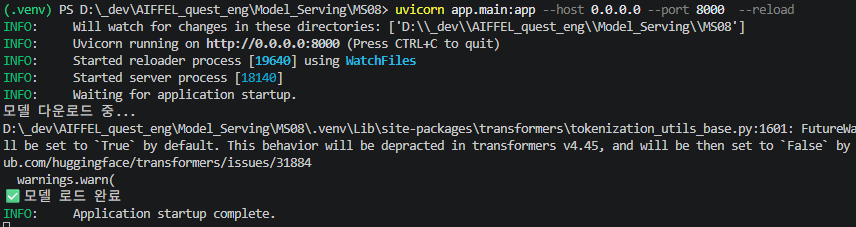

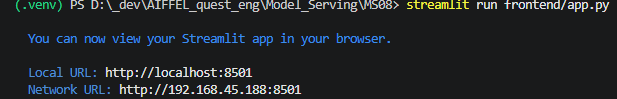

### 4.3 테스트

#### ✅ 서버가 정상적으로 실행되는가?

##### 1) 헬스 체크

In [ ]:
import requests
# 헬스체크 엔드포인트 호출
response = requests.get("http://localhost:8000/health")
print(f"상태 코드: {response.status_code}")
print(f"응답: {response.json()}")

INFO:     127.0.0.1:63240 - "GET /health HTTP/1.1" 200 OK
상태 코드: 200
응답: {'status': 'healthy', 'model_loaded': True}


##### 2) 루트 엔드포인트 호출 체크

In [ ]:
import requests
# 루트 엔드포인트 호출
response = requests.get("http://localhost:8000/")
print(f"상태 코드: {response.status_code}")
print(f"응답: {response.json()}")

INFO:     127.0.0.1:63248 - "GET / HTTP/1.1" 404 Not Found
상태 코드: 404
응답: {'detail': 'Not Found'}


app/main.py에 아래 코드 추가
```
@app.get("/")
def read_root():
    return {"message": "Welcome to Global Narrative to Tag API!"}
```

In [4]:
import requests
# 루트 엔드포인트 호출
response = requests.get("http://localhost:8000/")
print(f"상태 코드: {response.status_code}")
print(f"응답: {response.json()}")

상태 코드: 200
응답: {'message': 'Welcome to Global Narrative to Tag API!'}


#### ✅ Swagger UI에서 추론이 동작하는가?

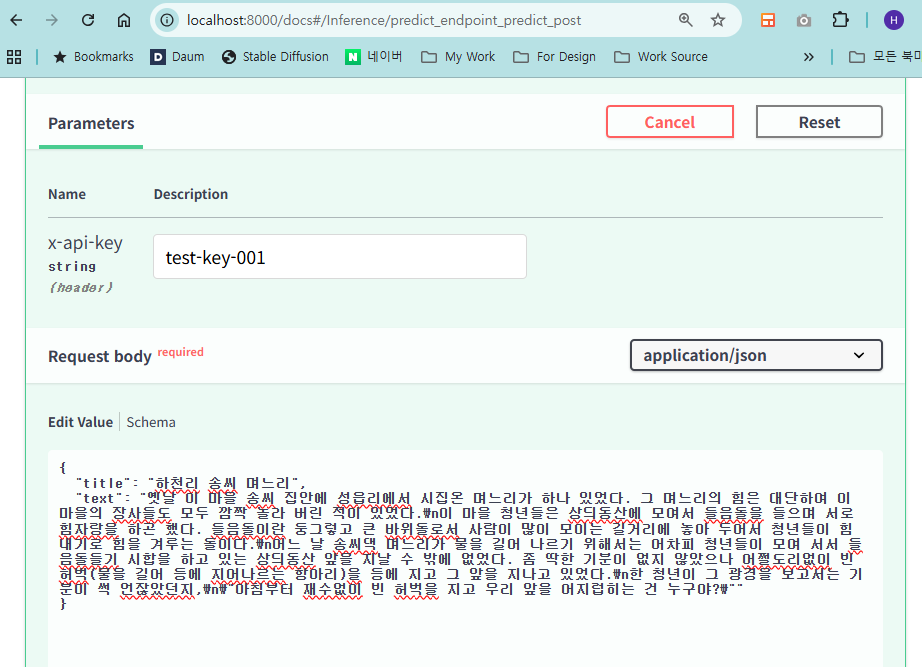

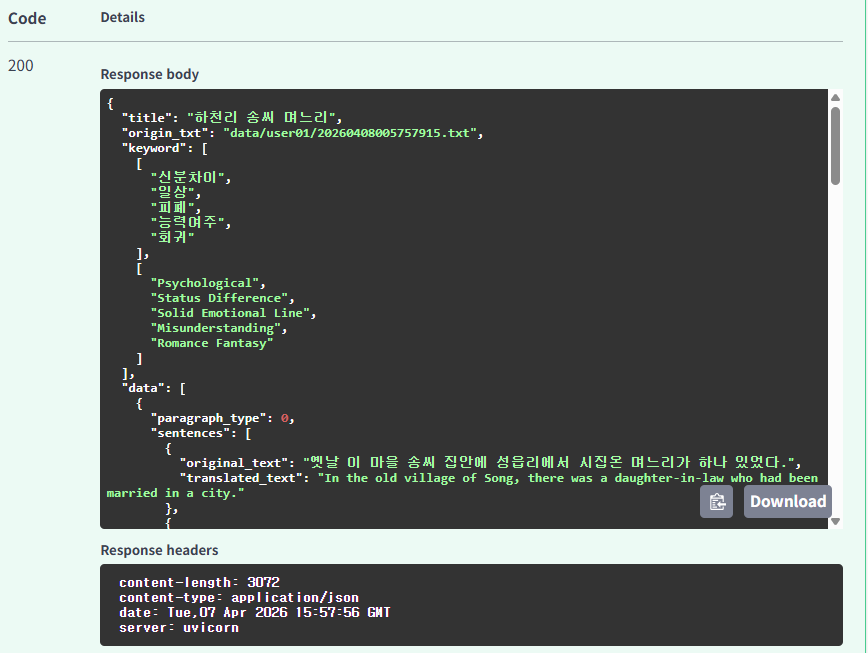

#### ✅ API Key 없이 요청하면 401이 반환되는가?

In [1]:
import requests

API_URL = "http://localhost:8000"

# health check
print(requests.get(f"{API_URL}/health").json())

HEADERS = {
    "Content-Type": "application/json"
}

# 추론 테스트 — 본인의 입력에 맞게 수정하세요
response = requests.post(
    f"{API_URL}/predict",
    json={
        "title": "하천리 송씨 며느리",
        "text": "하천리에는 ‘냇끼’라는 옛 이름이 있다. 제주에서 가장 긴 냇가를 끼고 있는 마을이라 붙은 이름이라는데, 요즘 말로 하면 그냥 \“물길 맛집 동네\”쯤 되는 셈이다."
    },   # ← 수정
    headers=HEADERS,
)
print(f"상태: {response.status_code}")
print(f"결과: {response.json()}")

{'status': 'healthy', 'model_loaded': True}
상태: 401
결과: {'detail': 'API Key가 필요합니다. X-API-Key 헤더를 포함해 주세요.'}


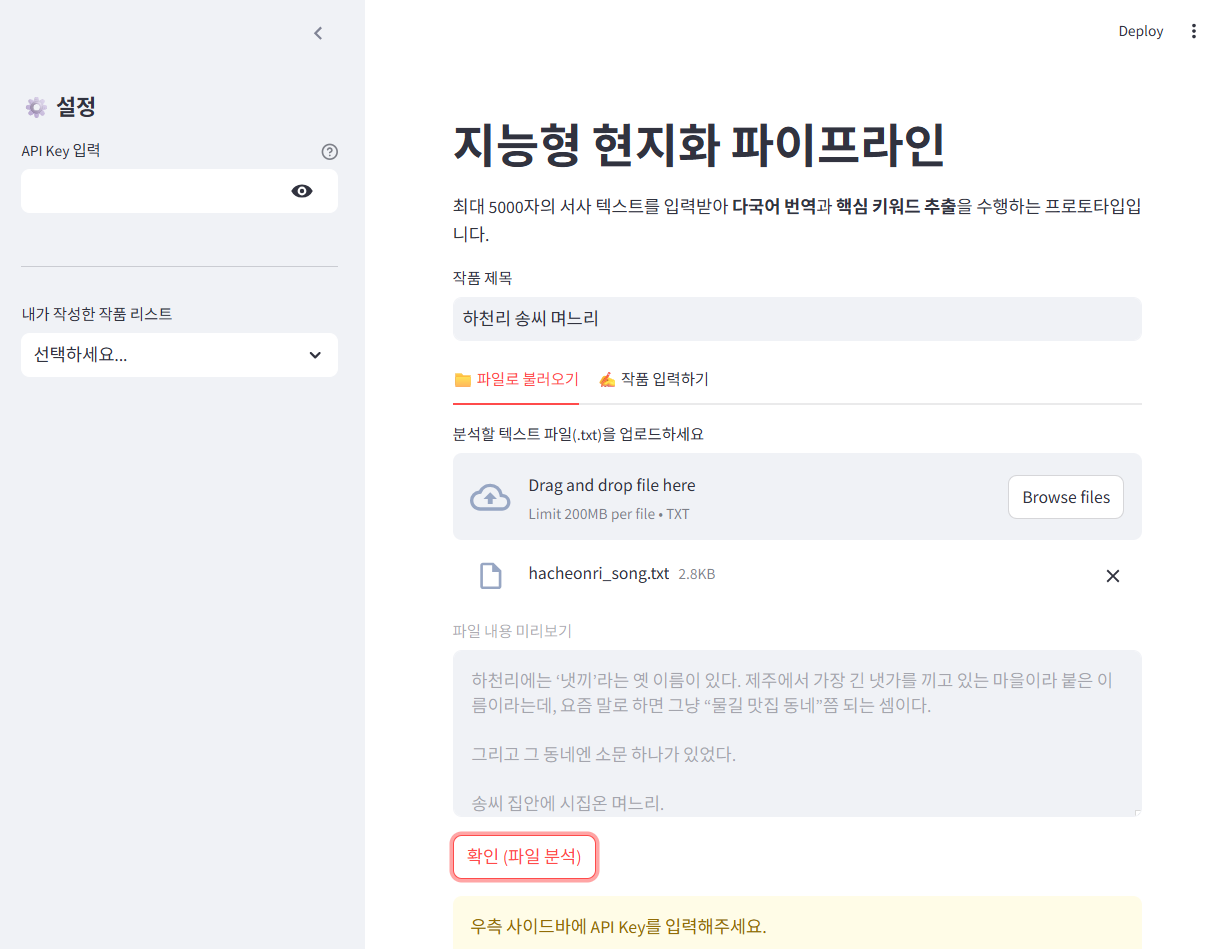

#### ✅ 잘못된 입력에 대해 적절한 에러 메시지가 나오는가?

In [2]:
import requests

API_URL = "http://localhost:8000"

# health check
print(requests.get(f"{API_URL}/health").json())

HEADERS = {"X-API-Key": "test-key-001"}

# 추론 테스트 — 본인의 입력에 맞게 수정하세요
response = requests.post(
    f"{API_URL}/predict",
    json={
        "title": "하천리 송씨 며느리"
    },   # ← 수정
    headers=HEADERS,
)
print(f"상태: {response.status_code}")
print(f"결과: {response.json()}")

{'status': 'healthy', 'model_loaded': True}
상태: 422
결과: {'detail': [{'type': 'missing', 'loc': ['body', 'text'], 'msg': 'Field required', 'input': {'title': '하천리 송씨 며느리'}}]}


#### ✅ Streamlit UI에서 입력 → 결과 확인이 가능한가?

##### [입력창]

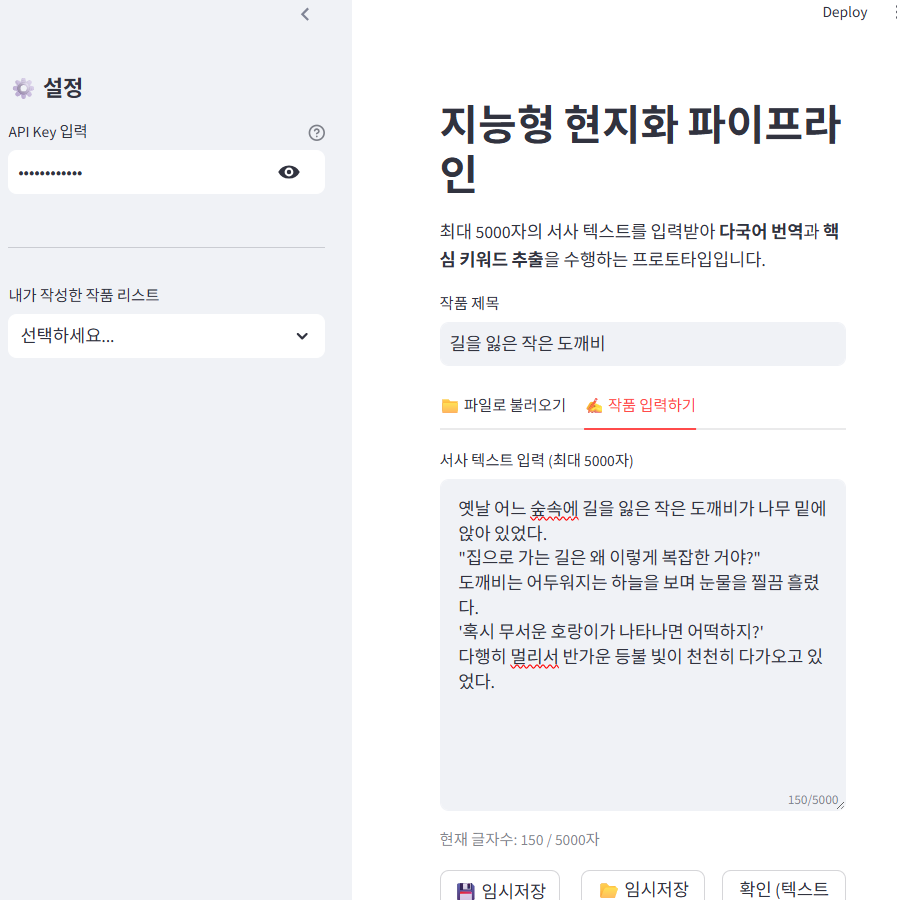